In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy import stats as sps
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree, plot_tree
from xgboost import XGBClassifier, XGBRegressor


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


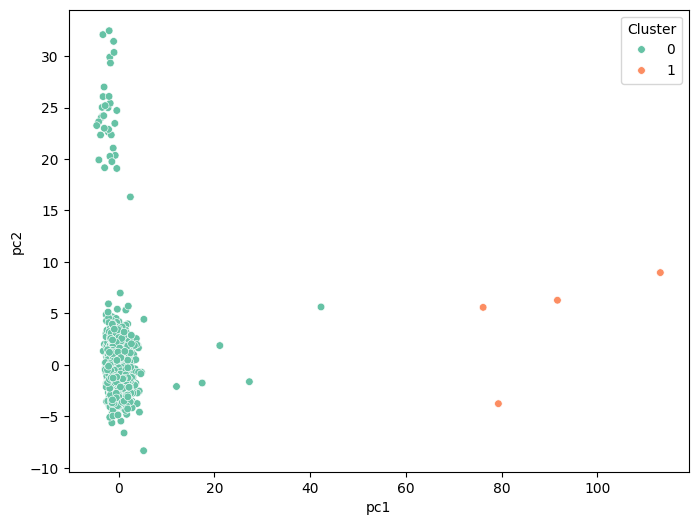

In [47]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

---
---

In [ ]:
def stagewise_blockwise_fixed_order(Z_scaled, y, block_size, max_blocks=None):
    """
    固定順序、分段(one-pass) stagewise。
    回傳：intercept, coef_scaled(p,), y_hat(n,)
    """
    Z = np.asarray(Z_scaled, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    n, p = Z.shape

    # 欄中心化/標準化（不改 Z 本體，避免尺度問題）
    mu = Z.mean(axis=0)
    sd = Z.std(axis=0) + 1e-12
    Zs = (Z - mu) / sd

    intercept = float(y.mean())
    r = y - intercept
    coef_zs = np.zeros(p, dtype=float)

    n_blocks = int(np.ceil(p / block_size))
    if max_blocks is not None:
        n_blocks = min(n_blocks, int(max_blocks))

    for bi in range(n_blocks):
        j0 = bi * block_size
        j1 = min(p, (bi + 1) * block_size)

        for j in range(j0, j1):
            x = Zs[:, j]
            denom = float(x @ x)
            if denom == 0.0:
                continue
            a = float((x @ r) / denom)
            c = float(r.mean())
            r = r - (a * x + c)
            coef_zs[j] += a
            intercept += c

    # 還原到 Z_scaled 座標：y ≈ b0 + Z_scaled @ b
    b = coef_zs / sd
    b0 = intercept - float(mu @ b)

    y_hat = b0 + Z @ b
    return b0, b, y_hat

def local_surrogate_lattice_cube_linear(
    x0,
    blackbox_model,
    n_samples,
    delta,                     # 標準化空間格點步長
    max_full_grid,             # 允許完整展開的最大點數
    k=None,                    # 若給定則固定半徑層數；否則依 n_samples 自動估
    random_state=None,
    scaler=None,
):
    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0, dtype=float).reshape(1, -1)
    x0_scaled = scaler.transform(x0) if scaler is not None else x0.copy()
    p = x0_scaled.shape[1]
    if p < 1:
        raise ValueError("x0 必須至少有 1 個特徵")
    if n_samples < 1:
        raise ValueError("n_samples must be >= 1")

    # 2) 決定 k：使 (2k+1)^p >= n_samples（僅用於定義 cube 範圍）
    if k is None:
        # 取最小 k 讓總格點數 >= n_samples（理論上，實作用浮點估算再校正）
        k_est = (n_samples ** (1.0 / p) - 1.0) / 2.0
        k = int(np.ceil(max(0.0, k_est)))
        k = max(1, k) if n_samples > 1 else 0
    else:
        k = int(k)
        if k < 0:
            raise ValueError("k must be >= 0")

    total = (2 * k + 1) ** p if k > 0 else 1

    # 3) 生成 offsets：m ∈ {-k,...,k}^p
    #    - total 小：展開 full grid 再截取/洗牌
    #    - total 大：直接在整數 cube 上抽樣 n_samples 個 m（仍是格點）
    if total <= max_full_grid:
        grid_1d = np.arange(-k, k + 1, dtype=float)
        meshes = np.meshgrid(*([grid_1d] * p), indexing="ij")
        offsets = np.stack(meshes, axis=-1).reshape(-1, p)  # (total, p)

        # 把中心 0 向量放在第 0 個，其他洗牌後取 n_samples
        # 找到全零那列
        zero_idx = np.where((offsets == 0).all(axis=1))[0][0]
        if zero_idx != 0:
            offsets[[0, zero_idx]] = offsets[[zero_idx, 0]]

        if len(offsets) > 1:
            perm = np.arange(1, len(offsets))
            rng.shuffle(perm)
            offsets = np.vstack([offsets[0], offsets[perm]])

        offsets = offsets[:n_samples] if len(offsets) >= n_samples else offsets
        mode = "full_grid"
    else:
        offsets = rng.integers(-k, k + 1, size=(n_samples, p)).astype(float)
        offsets[0, :] = 0.0  # 強制包含中心
        mode = "sampled_grid"

    # 4) 形成 lattice cube 設計點（標準化空間）
    Z_scaled = x0_scaled + delta * offsets

    # 5) 還原回原始空間（給 blackbox）
    Z = scaler.inverse_transform(Z_scaled) if scaler is not None else Z_scaled.copy()

    # 6) blackbox oracle 產生 pseudo-label
    if hasattr(blackbox_model, "predict_proba"):
        y_local = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y_local = blackbox_model.predict(Z)
    y_local = np.asarray(y_local, dtype=float).reshape(-1)

    # 7) \hat{\hat g}：Stagewise blockwise（在標準化空間擬合）
    b0, b, y_hat = stagewise_blockwise_fixed_order(Z_scaled, y_local, block_size=20)

    # 8) 線性模型常用 criterion：R2 / adj-R2 / AIC / BIC
    n = Z_scaled.shape[0]
    resid = y_local - y_hat
    sse = float(resid @ resid)
    mse = sse / n if n > 0 else np.nan

    # R2（用定義算，避免依賴 sklearn）
    tss = float(((y_local - y_local.mean()) ** 2).sum())
    r2 = 1.0 - (sse / tss) if tss > 0 else np.nan
    
    # Adjusted R2
    if n > p + 1:
        adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - p - 1)
    else:
        adj_r2 = np.nan

    # AIC/BIC（高斯誤差近似；k_params = p 斜率 + 1 截距）
    k_params = p + 1
    if n > 0 and sse > 0:
        aic = n * np.log(sse / n) + 2 * k_params
        bic = n * np.log(sse / n) + np.log(n) * k_params
    else:
        aic = -np.inf
        bic = -np.inf

    info = {
        "mode": mode,                 # full_grid / sampled_grid
        "k": k,
        "delta": delta,
        "Z": Z,                       # 原始空間設計點（給 blackbox）
        "Z_scaled": Z_scaled,         # 標準化空間設計點（給 surrogate）
        "offsets": offsets,           # m ∈ {-k,...,k}^p（或其子集）
        "y_blackbox": y_local,
        "y_surrogate": y_hat,
        "r2": float(r2),
        "adj_r2": float(adj_r2) if np.isfinite(adj_r2) else adj_r2,
        "aic": float(aic),
        "bic": float(bic),
        "mse": float(mse) if np.isfinite(mse) else mse,
        "coef_scaled": b.copy(),
        "intercept": float(b0),
    }
    # --- OLS summary (最小增量) ---
    X_ols = sm.add_constant(Z_scaled)          # 截距
    ols_res = sm.OLS(y_local, X_ols).fit()
    info["ols_summary"] = ols_res.summary().as_text()
    return None, info


---
---

依照KMEANS分的cluster=0/1各自去做surrogate

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# ========= per-cluster local surrogate =========
def run_local_surrogates_per_cluster(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    n_samples=500, delta=0.1, topk=10, random_state=42
):
    all_infos = []

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx_c]
        m  = blackbox_by_c[c]

        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        # 兩組 x0：p≈0.5 與 p≈1
        loc_05 = pick_x0_indices(p_hat_c, target=0.5, topk=topk)
        loc_1  = pick_x0_indices(p_hat_c, target=1, topk=topk)

        def _one_group(loc_idx, tag):
            loc_idx = np.asarray(loc_idx, dtype=int)
            if len(loc_idx) == 0:
                return []
            infos = []
            # loc_idx 是在該 cluster 內的「位置索引」(pos)，先轉成全域索引
            global_ids = [int(idx_c[pos]) for pos in loc_idx]
            X0 = X_all_df.iloc[global_ids].to_numpy()        # (m, p)
            x_center = X0.mean(axis=0)                       # (p,)
            # 只跑一次 surrogate：以「這一組點的平均」當中心
            g, info = local_surrogate_lattice_cube_linear(
                x0=x_center,
                blackbox_model=m,   # 用該群 blackbox
                n_samples=n_samples,
                delta=delta,
                max_full_grid=200_000,
                k=10,
                random_state=random_state,
                scaler=None,        # 已在標準化空間
            )
            info["cluster"]   = int(c)
            info["group"]     = tag
            info["i"]         = 0
            # 記錄這次中心是由哪些點平均而來
            info["x0_indices"] = global_ids
            # 這一組點的 OOF 機率（用平均/中位數都可；這裡用平均）
            info["p_oof_x0_mean"] = float(np.asarray(p_hat_c)[loc_idx].mean())
            # 最終模型在中心點 x_center 的機率
            info["p_final_x0_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])

            info["feature_names"] = list(X_all_df.columns)
            infos.append(info)
            return infos

        all_infos.extend(_one_group(loc_05, "p≈0.5"))
        all_infos.extend(_one_group(loc_1,  "p≈1(fail)"))

    return all_infos

infos_all = run_local_surrogates_per_cluster(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    n_samples=1000,
    delta=0.1,
    topk=10,
    random_state=42
)

# ========= metrics 表 =========
def infos_to_metrics_df(infos):
    rows = []
    for d in infos:
        rows.append({
            "cluster": d.get("cluster", None),
            "group": d.get("group", None),

            # 新版：中心點資訊
            "x0_indices": d.get("x0_indices", None),
            "n_x0": (len(d["x0_indices"]) if isinstance(d.get("x0_indices", None), list) else np.nan),

            # 新版：中心點機率
            "p_oof_center": d.get("p_oof_x0_mean", np.nan),
            "p_final_center": d.get("p_final_x0_center", np.nan),

            # surrogate 品質
            "r2": d.get("r2", np.nan),
            "adj_r2": d.get("adj_r2", np.nan),
            "aic": d.get("aic", np.nan),
            "bic": d.get("bic", np.nan),
            "mse": d.get("mse", np.nan),
            "k": d.get("k", None),
            "delta": d.get("delta", None),
            "mode": d.get("mode", None),
        })
    # 你現在每群每組只有一筆，所以用 cluster+group 排就好
    return pd.DataFrame(rows).sort_values(["cluster", "group"]).reset_index(drop=True)

df_metrics = infos_to_metrics_df(infos_all)
df_metrics

In [ ]:
def local_sensitivity_summary(info, topk=20, as_dataframe=True):
    """
    只針對某個 x0 的 local surrogate：
    回傳局部敏感度排名（|coef_scaled|），不代入任何其他點、不輸出 y_hat。
    """
    coef = np.asarray(info["coef_scaled"], dtype=float).reshape(-1)
    names = info.get("feature_names", [f"x{j}" for j in range(len(coef))])

    df = pd.DataFrame({
        "feature": names,
        "coef_scaled": coef,
        "abs_coef": np.abs(coef),
        "sign": np.sign(coef),
    }).sort_values("abs_coef", ascending=False)

    if topk is not None:
        df = df.head(int(topk)).reset_index(drop=True)

    return df if as_dataframe else df.to_dict("records")


info = infos_all[1]  # 某個 x0 的 local surrogate
df_top = local_sensitivity_summary(info, topk=20)
df_top

In [ ]:
print(infos_all[0]["ols_summary"])

---
---

In [7]:
def _fullgrid_offsets(q, k):
    """
    回傳 offsets_q: shape (n, q), n=(2k+1)^q
    並保證第一列是全 0（中心點）。
    """
    grid_1d = np.arange(-k, k + 1, dtype=float)
    meshes = np.meshgrid(*([grid_1d] * q), indexing="ij")
    offsets = np.stack(meshes, axis=-1).reshape(-1, q)

    zero_idx = np.where((offsets == 0).all(axis=1))[0][0]
    if zero_idx != 0:
        offsets[[0, zero_idx]] = offsets[[zero_idx, 0]]
    return offsets


def local_surrogate_block_fullgrid_ols(
    x0,
    blackbox_model,
    block_cols,               # list/array of feature indices used in this block (len=q)
    delta,
    k,
    scaler=None,
    chunk_size=10000,
    store_yhat=False,
):
    """
    只在 block_cols 這 q 個維度做 full grid，其餘維固定 x0。
    回傳：info（含 coef/se/t/p, p-value, y_blackbox, optional y_hat）
    """
    x0 = np.asarray(x0, float).reshape(1, -1)
    x0_scaled = scaler.transform(x0) if scaler is not None else x0.copy()
    p = x0_scaled.shape[1]

    block_cols = np.asarray(block_cols, dtype=int)
    q = block_cols.size
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")

    offsets_q = _fullgrid_offsets(q, k)                 # (n, q)
    n = offsets_q.shape[0]

    # 用 dx 作為回歸自變數：dx = delta * offsets（在 scaled 空間的擾動量）
    X_block = delta * offsets_q                         # (n, q)

    # 黑箱查詢：chunk 生成 n×p，避免一次存滿
    y_local = np.empty(n, dtype=float)

    for s in range(0, n, chunk_size):
        e = min(n, s + chunk_size)

        Zs_chunk = np.repeat(x0_scaled, e - s, axis=0)  # (chunk, p)
        Zs_chunk[:, block_cols] += X_block[s:e, :]      # 只改 block 維度

        Z_chunk = scaler.inverse_transform(Zs_chunk) if scaler is not None else Zs_chunk

        if hasattr(blackbox_model, "predict_proba"):
            y_local[s:e] = blackbox_model.predict_proba(Z_chunk)[:, 1]
        else:
            y_local[s:e] = blackbox_model.predict(Z_chunk)

    y_local = y_local.reshape(-1)

    # OLS：y ~ b0 + X_block @ b
    X_design = sm.add_constant(X_block, has_constant="add")
    res = sm.OLS(y_local, X_design).fit()

    info = {
        "n": int(n),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "y_blackbox": y_local,
        "coef_block": res.params[1:].copy(),     # (q,)
        "intercept": float(res.params[0]),
        "se_block": res.bse[1:].copy(),
        "t_block": res.tvalues[1:].copy(),
        "p_block": res.pvalues[1:].copy(),
        "intercept_p": float(res.pvalues[0]),
        "r2": float(res.rsquared) if hasattr(res, "rsquared") else np.nan,
        "adj_r2": float(res.rsquared_adj) if hasattr(res, "rsquared_adj") else np.nan,
        "aic": float(res.aic) if hasattr(res, "aic") else np.nan,
        "bic": float(res.bic) if hasattr(res, "bic") else np.nan,
    }

    if store_yhat:
        info["y_surrogate"] = res.fittedvalues.copy()

    return info


def run_blockwise_fullgrid_pvalues(
    x0,
    blackbox_model,
    feature_names,
    block_size,
    k,
    delta=0.1,
    scaler=None,
    chunk_size=10000,
):
    """
    依 feature 順序切 block，每個 block 做 full grid + OLS，
    輸出一張全 p 特徵的 coef/se/t/p 表。
    """
    p = len(feature_names)
    rows = []

    n_blocks = int(np.ceil(p / block_size))
    for bi in range(n_blocks):
        j0 = bi * block_size
        j1 = min(p, (bi + 1) * block_size)
        block_cols = list(range(j0, j1))

        info = local_surrogate_block_fullgrid_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=block_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            chunk_size=chunk_size,
            store_yhat=False,
        )

        for t, col in enumerate(block_cols):
            rows.append({
                "feature_idx": int(col),
                "feature": feature_names[col],
                "block_id": int(bi),
                "coef": float(info["coef_block"][t]),
                "se": float(info["se_block"][t]),
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "abs_coef": float(abs(info["coef_block"][t])),
                "n_grid": info["n"],
                "k": info["k"],
                "delta": info["delta"],
            })

    df = pd.DataFrame(rows)

    # 重要性：p 小→前面；同 p 下用 |coef| 大→前面
    df = df.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
    df["rank_p"] = np.arange(1, len(df) + 1)

    return df




In [8]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# ========= per-cluster local surrogate =========
def run_block_pvalues_per_cluster_center(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=5, target=0.5,                 # 用 OOF 挑點
    block_size=20, k=1, delta=0.1,
    random_state=42,
):
    out = []
    feature_names = list(X_all_df.columns)

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_p = run_blockwise_fullgrid_pvalues(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            block_size=block_size,
            k=k,
            delta=delta,
            scaler=None,
            chunk_size=10000,
        )

        # 補上 meta
        df_p["cluster"] = int(c)
        df_p["x0_indices"] = [global_ids] * len(df_p)
        df_p["p_oof_center"] = float(p_hat_c[loc].mean())
        df_p["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])

        out.append(df_p)

    return pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()

df_all_p = run_block_pvalues_per_cluster_center(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=10,
    target=0.5,
    block_size=20,
    k=1,
    delta=0.1,
)
df_all_p.head(50)


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_20132\2039533417.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


MemoryError: Unable to allocate 26.0 GiB for an array with shape (3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3) and data type float64

In [ ]:
# 每群各取前 30 個最顯著特徵
top_by_cluster = (
    df_all_p
    .sort_values(["cluster","p","abs_coef"], ascending=[True, True, False])
    .groupby("cluster")
    .head(30)
)
top_by_cluster

In [11]:
def _center_index(q, k):
    # all-zero offset 對應 base-(2k+1) 數字每位都是 k
    B = 2 * k + 1
    return int(k * (B**q - 1) // (B - 1)) if B != 1 else 0


def _offsets_from_linear_indices(idx, q, k):
    """
    idx: (m,) 的線性索引，對應 meshgrid 展開後的順序（lex order）
    回傳 offsets: (m, q)，每列是 [-k..k] 的 q 維整數位移（float）
    """
    idx = idx.astype(np.int64, copy=False)
    B = 2 * k + 1
    m = idx.size
    offsets = np.empty((m, q), dtype=float)
    x = idx.copy()
    for d in range(q - 1, -1, -1):
        x, r = np.divmod(x, B)
        offsets[:, d] = r.astype(float) - k
    return offsets


def _iter_fullgrid_offsets_chunked(q, k, chunk_size, center_first=True):
    """
    以 chunk 方式產生 full grid offsets，不一次存滿 (2k+1)^q × q。
    若 center_first=True，先 yield 全 0 offset，再 yield 其餘點（不重複）。
    """
    B = 2 * k + 1
    n = int(B**q)

    if center_first:
        cidx = _center_index(q, k)
        yield np.zeros((1, q), dtype=float), np.array([cidx], dtype=np.int64), n

        # 0..n-1 排除 cidx
        s = 0
        while s < n:
            e = min(n, s + chunk_size)
            idx = np.arange(s, e, dtype=np.int64)
            mask = idx != cidx
            if mask.any():
                idx2 = idx[mask]
                yield _offsets_from_linear_indices(idx2, q, k), idx2, n
            s = e
    else:
        s = 0
        while s < n:
            e = min(n, s + chunk_size)
            idx = np.arange(s, e, dtype=np.int64)
            yield _offsets_from_linear_indices(idx, q, k), idx, n
            s = e


def _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n, q):
    """
    用累積量求 OLS 係數與統計量
    Sxx = X'X (q+1,q+1), Sxy = X'y (q+1,), Syy = y'y, sum_y = sum(y)
    """
    p_params = q + 1
    df_resid = n - p_params
    out = {}

    # beta
    try:
        beta = np.linalg.solve(Sxx, Sxy)
    except np.linalg.LinAlgError:
        beta = np.full(p_params, np.nan)

    # SSE = y'y - 2 b'X'y + b'X'X b
    if np.all(np.isfinite(beta)):
        SSE = float(Syy - 2.0 * beta @ Sxy + beta @ (Sxx @ beta))
    else:
        SSE = np.nan

    # TSS
    ybar = float(sum_y / n) if n > 0 else np.nan
    TSS = float(Syy - n * (ybar**2)) if n > 0 else np.nan

    # sigma2, cov, se, t, p
    if df_resid > 0 and np.isfinite(SSE):
        sigma2 = SSE / df_resid
    else:
        sigma2 = np.nan

    try:
        Sxx_inv = np.linalg.inv(Sxx)
    except np.linalg.LinAlgError:
        Sxx_inv = np.full_like(Sxx, np.nan)

    if np.isfinite(sigma2) and np.all(np.isfinite(Sxx_inv)):
        cov = sigma2 * Sxx_inv
        se = np.sqrt(np.diag(cov))
        tval = beta / se
        if sps is not None and df_resid > 0:
            pval = 2.0 * (1.0 - sps.t.cdf(np.abs(tval), df=df_resid))
        else:
            pval = np.full_like(tval, np.nan, dtype=float)
    else:
        se = np.full(p_params, np.nan)
        tval = np.full(p_params, np.nan)
        pval = np.full(p_params, np.nan)

    # r2
    if np.isfinite(SSE) and np.isfinite(TSS) and TSS > 0:
        r2 = 1.0 - SSE / TSS
    else:
        r2 = np.nan

    if np.isfinite(r2) and df_resid > 0:
        adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / df_resid
    else:
        adj_r2 = np.nan

    # aic/bic（與 statsmodels OLS 近似一致的高斯假設形式）
    # aic = n*log(SSE/n) + 2*k ; bic = n*log(SSE/n) + log(n)*k
    kparam = p_params
    if n > 0 and np.isfinite(SSE) and SSE > 0:
        ll_term = n * np.log(SSE / n)
        aic = float(ll_term + 2.0 * kparam)
        bic = float(ll_term + np.log(n) * kparam)
    else:
        aic = np.nan
        bic = np.nan

    out["beta"] = beta
    out["SSE"] = SSE
    out["r2"] = float(r2) if np.isfinite(r2) else np.nan
    out["adj_r2"] = float(adj_r2) if np.isfinite(adj_r2) else np.nan
    out["se"] = se
    out["t"] = tval
    out["p"] = pval
    out["aic"] = aic
    out["bic"] = bic
    out["df_resid"] = int(df_resid) if df_resid >= 0 else int(df_resid)
    return out


def local_surrogate_block_fullgrid_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    chunk_size=10000,
    store_yhat=False,
    store_yblackbox=False,
):
    """
    串流版：不建立完整 offsets/X/y，改累積 X'X, X'y, y'y, sum(y)。
    注意：store_yhat/store_yblackbox=True 只適合 n 很小，否則會爆記憶體。
    """
    x0 = np.asarray(x0, float).reshape(1, -1)
    x0_scaled = scaler.transform(x0) if scaler is not None else x0.copy()
    p = x0_scaled.shape[1]

    block_cols = np.asarray(block_cols, dtype=int)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")

    B = 2 * k + 1
    n_total = int(B**q)

    if store_yhat or store_yblackbox:
        # n_total 在 k=3,q=10 時極大，這兩者會直接把記憶體打爆
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    # sufficient stats
    Sxx = np.zeros((q + 1, q + 1), dtype=float)
    Sxy = np.zeros((q + 1,), dtype=float)
    Syy = 0.0
    sum_y = 0.0
    n_seen = 0

    for offsets_q, idx_linear, n_full in _iter_fullgrid_offsets_chunked(q, k, chunk_size, center_first=True):
        m = offsets_q.shape[0]
        if m == 0:
            continue

        X_block = delta * offsets_q  # (m,q)

        # 生成這批次完整 p 維輸入（scaled 空間）
        Zs_chunk = np.repeat(x0_scaled, m, axis=0)     # (m,p)
        Zs_chunk[:, block_cols] += X_block            # 只動 block

        Z_chunk = scaler.inverse_transform(Zs_chunk) if scaler is not None else Zs_chunk

        if hasattr(blackbox_model, "predict_proba"):
            y = blackbox_model.predict_proba(Z_chunk)[:, 1].astype(float, copy=False)
        else:
            y = blackbox_model.predict(Z_chunk).astype(float, copy=False)

        y = y.reshape(-1)
        if y.size != m:
            raise ValueError("blackbox 輸出長度與 chunk 不一致")

        # 設計矩陣（含截距）: X1 = [1, X_block]
        ones = np.ones((m, 1), dtype=float)
        X1 = np.hstack([ones, X_block])  # (m,q+1)

        # 累加 sufficient stats
        Sxx += X1.T @ X1
        Sxy += X1.T @ y
        Syy += float(y @ y)
        sum_y += float(y.sum())
        n_seen += int(m)

    if n_seen != n_total:
        # center_first 模式下仍應該完整覆蓋 n_total（中心點單獨+其餘點）
        raise RuntimeError(f"n_seen({n_seen}) != n_total({n_total})")

    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n_seen, q)

    info = {
        "n": int(n_seen),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "y_blackbox": None,  # 串流模式不保存
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "adj_r2": float(st["adj_r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
    }
    return info


def run_blockwise_fullgrid_pvalues(
    x0,
    blackbox_model,
    feature_names,
    block_size,
    k,
    delta=0.1,
    scaler=None,
    chunk_size=10000,
):
    """
    blockwise 串流 OLS 版：每個 block 不存 full grid 資料。
    """
    p = len(feature_names)
    rows = []

    n_blocks = int(np.ceil(p / block_size))
    for bi in range(n_blocks):
        j0 = bi * block_size
        j1 = min(p, (bi + 1) * block_size)
        block_cols = list(range(j0, j1))

        info = local_surrogate_block_fullgrid_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=block_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            chunk_size=chunk_size,
            store_yhat=False,
            store_yblackbox=False,
        )

        for t, col in enumerate(block_cols):
            rows.append({
                "feature_idx": int(col),
                "feature": feature_names[col],
                "block_id": int(bi),
                "coef": float(info["coef_block"][t]),
                "se": float(info["se_block"][t]),
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "abs_coef": float(abs(info["coef_block"][t])),
                "n_grid": info["n"],
                "k": info["k"],
                "delta": info["delta"],
                "r2_block": info["r2"],
                "adj_r2_block": info["adj_r2"],
                "df_resid": info["df_resid"],
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
    df["rank_p"] = np.arange(1, len(df) + 1)
    return df


In [12]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]
# 只改「呼叫端參數」到能撐住 k=3 的設定：
# 核心：block_size 必須改 10；k 改 3；chunk_size 保留 10000
# 其餘流程不動（最低限度修改）

def run_block_pvalues_per_cluster_center(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=5, target=0.5,
    block_size=10, k=3, delta=0.1,          # ← 改這裡
    random_state=42,
):
    out = []
    feature_names = list(X_all_df.columns)

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_p = run_blockwise_fullgrid_pvalues(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            block_size=block_size,           # ← 10
            k=k,                             # ← 3
            delta=delta,
            scaler=None,
            chunk_size=10000,                # ← 10000
        )

        df_p["cluster"] = int(c)
        df_p["x0_indices"] = [global_ids] * len(df_p)
        df_p["p_oof_center"] = float(p_hat_c[loc].mean())
        df_p["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])

        out.append(df_p)

    return pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()


df_all_p = run_block_pvalues_per_cluster_center(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=10,
    target=0.5,
    block_size=10,   # ← 改 10
    k=3,             # ← 改 3
    delta=0.1,
)
df_all_p.head(50)

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_20132\1586249422.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


,feature_idx,feature,block_id,coef,se,t,p,abs_coef,n_grid,k,delta,r2_block,adj_r2_block,df_resid,rank_p,cluster,x0_indices,p_oof_center,p_final_center
0,102,x112,10,-0.098230,2.347894e-06,-41837.403300,0.0,0.098230,282475249,3,0.1,0.861044,0.861044,282475238,1,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
1,120,x130,12,0.080726,2.998451e-06,26922.505671,0.0,0.080726,282475249,3,0.1,0.729775,0.729775,282475238,2,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
2,384,x489,38,-0.074666,1.548804e-06,-48208.589340,0.0,0.074666,282475249,3,0.1,0.891628,0.891628,282475238,3,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
3,63,x69,6,-0.071716,1.456551e-06,-49236.610504,0.0,0.071716,282475249,3,0.1,0.895639,0.895639,282475238,4,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
4,425,x557,42,-0.056932,1.880859e-06,-30269.220217,0.0,0.056932,282475249,3,0.1,0.792118,0.792118,282475238,5,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
5,419,x551,41,-0.050496,1.734638e-06,-29110.577356,0.0,0.050496,282475249,3,0.1,0.750000,0.750000,282475238,6,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
6,33,x36,3,-0.044920,1.581396e-06,-28405.013665,0.0,0.044920,282475249,3,0.1,0.745739,0.745739,282475238,7,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
7,272,x337,27,0.038257,1.253420e-06,30522.463205,0.0,0.038257,282475249,3,0.1,0.767337,0.767337,282475238,8,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
8,300,x369,30,-0.038089,1.355224e-06,-28105.506139,0.0,0.038089,282475249,3,0.1,0.749461,0.749461,282475238,9,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
9,230,x282,23,-0.035327,1.750210e-06,-20184.166683,0.0,0.035327,282475249,3,0.1,0.647190,0.647190,282475238,10,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943


In [13]:
df_all_p

,feature_idx,feature,block_id,coef,se,t,p,abs_coef,n_grid,k,delta,r2_block,adj_r2_block,df_resid,rank_p,cluster,x0_indices,p_oof_center,p_final_center
0,102,x112,10,-9.822978e-02,2.347894e-06,-4.183740e+04,0.0,9.822978e-02,282475249,3,0.1,0.861044,0.861044,282475238,1,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
1,120,x130,12,8.072581e-02,2.998451e-06,2.692251e+04,0.0,8.072581e-02,282475249,3,0.1,0.729775,0.729775,282475238,2,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
2,384,x489,38,-7.466568e-02,1.548804e-06,-4.820859e+04,0.0,7.466568e-02,282475249,3,0.1,0.891628,0.891628,282475238,3,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
3,63,x69,6,-7.171562e-02,1.456551e-06,-4.923661e+04,0.0,7.171562e-02,282475249,3,0.1,0.895639,0.895639,282475238,4,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
4,425,x557,42,-5.693213e-02,1.880859e-06,-3.026922e+04,0.0,5.693213e-02,282475249,3,0.1,0.792118,0.792118,282475238,5,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,89,x99,8,-3.295847e-21,6.429605e-07,-5.126048e-15,1.0,3.295847e-21,282475249,3,0.1,0.575479,0.575479,282475238,455,1,"[376, 274, 207, 59, 134, 178, 237, 117, 176, 144]",0.494366,0.025957
914,119,x129,11,-2.064861e-21,8.306773e-07,-2.485756e-15,1.0,2.064861e-21,282475249,3,0.1,0.786803,0.786803,282475238,456,1,"[376, 274, 207, 59, 134, 178, 237, 117, 176, 144]",0.494366,0.025957
915,179,x202,17,-6.526251e-22,5.418168e-07,-1.204513e-15,1.0,6.526251e-22,282475249,3,0.1,0.709299,0.709299,282475238,457,1,"[376, 274, 207, 59, 134, 178, 237, 117, 176, 144]",0.494366,0.025957
916,458,x590,45,2.029514e-21,1.942523e-06,1.044783e-15,1.0,2.029514e-21,40353607,3,0.1,0.743572,0.743572,40353597,458,1,"[376, 274, 207, 59, 134, 178, 237, 117, 176, 144]",0.494366,0.025957


In [15]:
df_all_p.to_csv('df_all.csv')

In [43]:
secom = pd.read_csv(data_path, sep='\t')
secom.head(10)

,Time,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x582,x583,x584,x585,x586,x587,x588,x589,x590,Pass/Fail
0,2008-07-19 11:55:00,3030.9300,2564.0000,2187.7333,1411.1265,1.3602,100.0000,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.7800,2465.1400,2230.4222,1463.6606,0.8294,100.0000,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.6100,2559.9400,2186.4111,1698.0172,1.5102,100.0000,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.7200,2479.9000,2199.0333,909.7926,1.3204,100.0000,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.2400,2502.8700,2233.3667,1326.5200,1.5334,100.0000,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
5,2008-07-19 17:53:00,2946.2500,2432.8400,2233.3667,1326.5200,1.5334,100.0000,100.3967,0.1235,1.5287,...,44.0077,0.4949,0.0189,0.0044,3.8276,0.0342,0.0151,0.0052,44.0077,-1
6,2008-07-19 19:44:00,3030.2700,2430.1200,2230.4222,1463.6606,0.8294,100.0000,102.3433,0.1247,1.5816,...,NaN,0.5010,0.0143,0.0042,2.8515,0.0342,0.0151,0.0052,44.0077,-1
7,2008-07-19 19:45:00,3058.8800,2690.1500,2248.9000,1004.4692,0.7884,100.0000,106.2400,0.1185,1.5153,...,95.0310,0.4984,0.0106,0.0034,2.1261,0.0204,0.0194,0.0063,95.0310,-1
8,2008-07-19 20:24:00,2967.6800,2600.4700,2248.9000,1004.4692,0.7884,100.0000,106.2400,0.1185,1.5358,...,111.6525,0.4993,0.0172,0.0046,3.4456,0.0111,0.0124,0.0045,111.6525,-1
9,2008-07-19 21:35:00,3016.1100,2428.3700,2248.9000,1004.4692,0.7884,100.0000,106.2400,0.1185,1.5381,...,90.2294,0.4967,0.0152,0.0038,3.0687,0.0212,0.0191,0.0073,90.2294,-1


In [22]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)

def cm_metrics(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    n = tn + fp + fn + tp

    acc = (tp + tn) / n if n else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan          # TPR / Sensitivity
    far = fp / (fp + tn) if (fp + tn) else np.nan             # FPR / False Alarm Rate
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan

    return {
        "n": n,
        "pos_rate(y=1)": (tp + fn) / n if n else np.nan,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "ACC": acc,
        "FAR(FPR)": far,
        "Recall(TPR)": recall,
        "Precision": precision,
        "F1": f1,
    }

def report_by_cluster(y_true, p_oof, c_all, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    p_oof = np.asarray(p_oof).astype(float)
    c_all = np.asarray(c_all).astype(int)

    rows = []

    # overall
    rows.append({"group": "ALL", **cm_metrics(y_true, p_oof, thr=thr)})

    # per cluster
    for c in np.unique(c_all):
        idx = np.where(c_all == c)[0]
        rows.append({"group": f"cluster_{c}", **cm_metrics(y_true[idx], p_oof[idx], thr=thr)})

    df = pd.DataFrame(rows)
    # 便於論文呈現的欄位順序
    cols = ["group", "n", "pos_rate(y=1)", "TN", "FP", "FN", "TP", "ACC", "FAR(FPR)", "Recall(TPR)", "Precision", "F1"]
    return df[cols]

# 以「每群 OOF 機率」作為黑箱分類效能的主報告（避免用同資料訓練再評估的樂觀偏誤）
thr = 0.5
df_report = report_by_cluster(y_real, p_hat_oof, c_all, thr=thr)

# 顯示
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(df_report)

# 若你要各群 confusion matrix（矩陣形式）
def confusion_matrix_by_cluster(y_true, p_oof, c_all, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    p_oof = np.asarray(p_oof).astype(float)
    c_all = np.asarray(c_all).astype(int)
    y_pred = (p_oof >= thr).astype(int)

    cms = {}
    cms["ALL"] = confusion_matrix(y_true, y_pred, labels=[0, 1])
    for c in np.unique(c_all):
        idx = np.where(c_all == c)[0]
        cms[f"cluster_{c}"] = confusion_matrix(y_true[idx], y_pred[idx], labels=[0, 1])
    return cms

cms = confusion_matrix_by_cluster(y_real, p_hat_oof, c_all, thr=thr)
for k, cm in cms.items():
    print(f"\n[{k}] confusion matrix (rows=true [0,1], cols=pred [0,1])\n{cm}")


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_30032\470622641.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


       group     n  pos_rate(y=1)    TN  FP  FN  TP    ACC  FAR(FPR)  \
0        ALL  1525         0.0623  1395  35  81  14 0.9239    0.0245   
1  cluster_0   772         0.0376   734   9  25   4 0.9560    0.0121   
2  cluster_1   753         0.0876   661  26  56  10 0.8911    0.0378   

   Recall(TPR)  Precision     F1  
0       0.1474     0.2857 0.1944  
1       0.1379     0.3077 0.1905  
2       0.1515     0.2778 0.1961  

[ALL] confusion matrix (rows=true [0,1], cols=pred [0,1])
[[1395   35]
 [  81   14]]

[cluster_0] confusion matrix (rows=true [0,1], cols=pred [0,1])
[[734   9]
 [ 25   4]]

[cluster_1] confusion matrix (rows=true [0,1], cols=pred [0,1])
[[661  26]
 [ 56  10]]


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


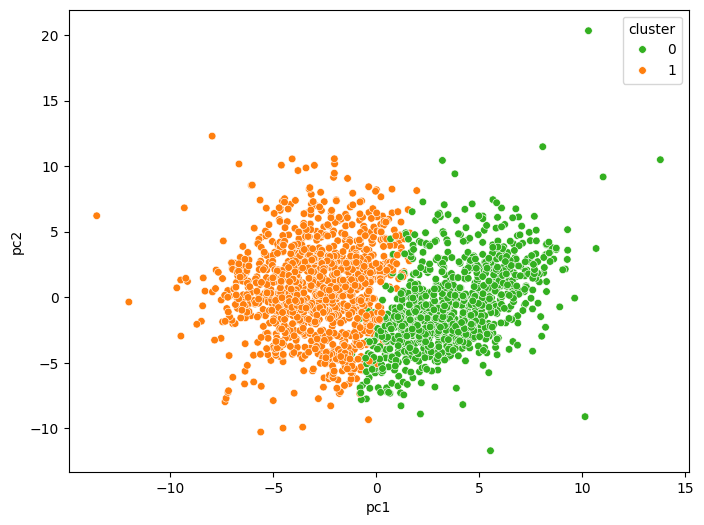

cluster sizes: {0: 948, 1: 1197}
cluster    0    1
y                
0        743  687
1        205  510


In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

X_pca_df['cluster'] = cluster

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())
df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)


ct1 = pd.crosstab(df.iloc[:1525,]['y'], df.iloc[:1525,]['label'], rownames=['y'], colnames=['cluster'])
print(ct1)